<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week11_Tutorial_Evaluating_Sanitation_Access_with_Bayesian_Methods_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scenario: You are part of an international NGO assessing whether access to improved sanitation facilities has increased after a 6-month intervention. You surveyed 100 people in each of 10 countries before and after the project. Your goal is to use Bayesian methods and Monte Carlo simulation to evaluate success across countries.

Step 1 – Load and Explore the Data

In [37]:
data <- read.csv("sdg6_sanitation_pre_post.csv")
head(data)

,Country,Pre_Improved_Sanitation,Post_Improved_Sanitation,Sample_Size
,<chr>,<int>,<int>,<int>
1,Kenya,56,70,100
2,Uganda,53,69,100
3,Tanzania,61,69,100
4,Rwanda,63,75,100
5,Ethiopia,47,65,100
6,Nepal,53,67,100


Step 2 – Define Prior Beliefs

In [38]:
# Assume a neutral belief: Beta(5, 5), meaning we think pre/post probabilities are likely around 50% but with uncertainty.

alpha_prior <- 5
beta_prior <- 5

Step 3 – Calculate Posterior for Each Country

In [39]:
data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation
data$Post_Beta <- beta_prior + (data$Sample_Size - data$Post_Improved_Sanitation)

In [40]:
# Prompt: Try repeating this for pre-intervention data to compare improvements.
data$Pre_Alpha <- alpha_prior + data$Pre_Improved_Sanitation
data$Pre_Beta  <- beta_prior + (data$Sample_Size - data$Pre_Improved_Sanitation)

Step 4 – Monte Carlo Simulation: Probability > 70%

In [41]:
# Simulate 10,000 draws from the posterior for each country and compute the chance that access exceeds 70%.

set.seed(42)
data$Prob_Above_70 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha[i], data$Post_Beta[i])
  mean(samples > 0.7)
})

# Interpretation: This value tells you the confidence that sanitation access is now above 70%.

Step 5 – Visualize a Country's Posterior

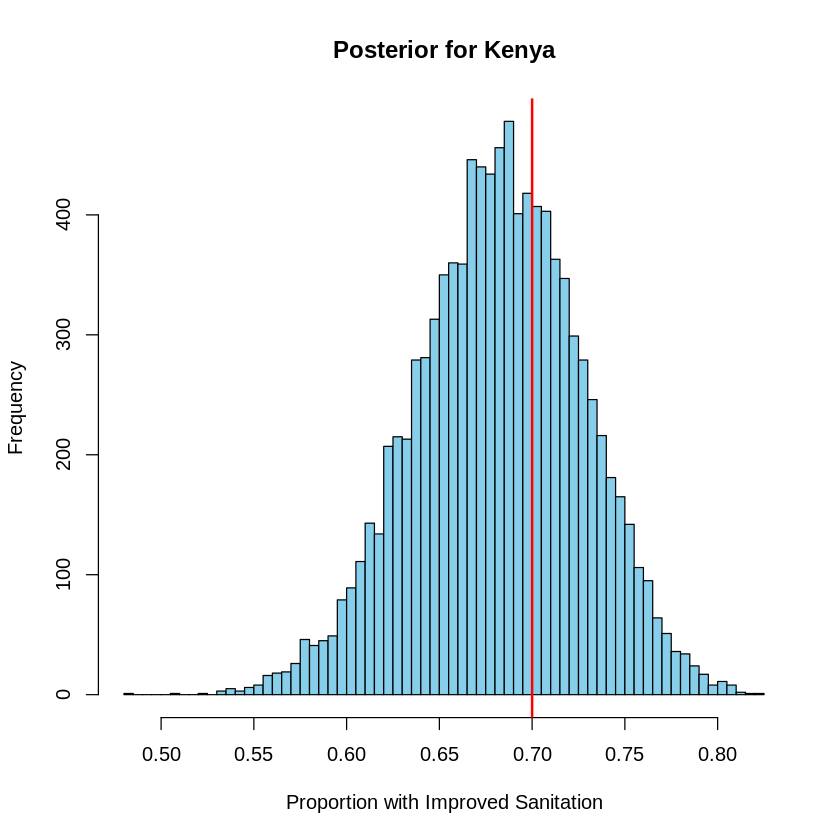

In [42]:
samples <- rbeta(10000, data$Post_Alpha[1], data$Post_Beta[1])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[1]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)

Interpret:

this histogram visualizes the posterior probability distribution for Kenya after 10,000 Monte Carlo draws from a $\text{Beta}(75, 35)$ distribution. It displays a symmetric, bell-shaped curve centered at the posterior mean of approximately $0.682$ ($68.2\%$ access rate). The vertical red line drawn at $0.70$ highlights the SDG target threshold; the portion of the distribution to the right of the line represents the $34.57\%$ probability that Kenya’s true access rate exceeds $70\%$, while the larger area to the left ($65.43\%$) illustrates that despite reaching 70 counts in the survey sample, there remains a substantial likelihood that the true population access rate still falls short of the target.

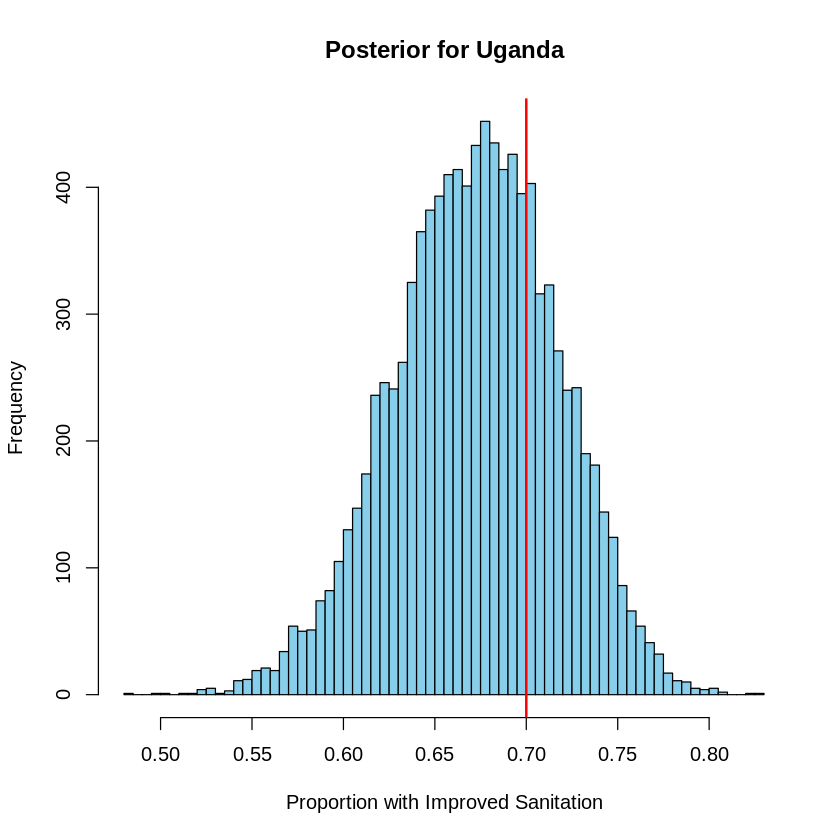

In [43]:
#Prompt: Try this for other countries using data$Post_Alpha[n] and data$Post_Beta[n]

# Set the country index
n <- 2

samples <- rbeta(10000, data$Post_Alpha[n], data$Post_Beta[n])
hist(samples, breaks = 50, col = "skyblue",
     main = paste("Posterior for", data$Country[n]),
     xlab = "Proportion with Improved Sanitation")
abline(v = 0.7, col = "red", lwd = 2)

Step 6 – Summary Table

In [44]:
summary_table <- data[c("Country", "Post_Improved_Sanitation", "Prob_Above_70")]
print(summary_table)

      Country Post_Improved_Sanitation Prob_Above_70
1       Kenya                       70        0.3457
2      Uganda                       69        0.2750
3    Tanzania                       69        0.2775
4      Rwanda                       75        0.7426
5    Ethiopia                       65        0.0771
6       Nepal                       67        0.1568
7  Bangladesh                       71        0.4322
8    Cambodia                       75        0.7430
9       Haiti                       70        0.3567
10  Guatemala                       68        0.2113


Interpret:

Following the 6-month intervention, posterior probabilities of meeting the $70\%$ target threshold vary widely across the 10 surveyed countries based on their post-intervention counts. Cambodia ($74.30\%$) and Rwanda ($74.26\%$) show the highest likelihood of success after reaching 75 counts per 100 surveyed, while countries hitting $70–71$ counts—such as Bangladesh ($43.22\%$), Haiti ($35.67\%$), and Kenya ($34.57\%$)—exhibit moderate confidence due to remaining statistical uncertainty. Conversely, lower-performing sites like Ethiopia ($7.71\%$), Nepal ($15.68\%$), and Guatemala ($21.13\%$) remain unlikely to have reached the target threshold, demonstrating that achieving $\ge 70$ successes in a sample of 100 does not guarantee high statistical certainty that the underlying population proportion exceeds $70\%$.

Step 7 – Try These Modifications

In [48]:
# Change the prior to Beta(1, 1) or Beta(10, 10) – what happens?
# Option A:
alpha_prior <- 1
beta_prior  <- 1

# Option B
 #alpha_prior <- 10
 #beta_prior  <- 10

# Recalculate Posteriors
data$Post_Alpha <- alpha_prior + data$Post_Improved_Sanitation
data$Post_Beta  <- beta_prior  + (data$Sample_Size - data$Post_Improved_Sanitation)

#simulating data
set.seed(42)
data$Prob_Above_70 <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Post_Alpha[i], data$Post_Beta[i])
  mean(samples > 0.7)
})

#summary
summary_table <- data[c("Country", "Post_Improved_Sanitation", "Prob_Above_70")]
print(summary_table)

      Country Post_Improved_Sanitation Prob_Above_70
1       Kenya                       70        0.4786
2      Uganda                       69        0.3897
3    Tanzania                       69        0.3893
4      Rwanda                       75        0.8504
5    Ethiopia                       65        0.1258
6       Nepal                       67        0.2388
7  Bangladesh                       71        0.5664
8    Cambodia                       75        0.8525
9       Haiti                       70        0.4873
10  Guatemala                       68        0.3092


Change the prior to Beta(1, 1) relies more on the survey data increases Prob_Above_70 for all countries

Change the prior to Beta(10, 10)exerts stronger shrinkage toward 50% and decreases Prob_Above_70 for all countries

In [46]:
# Run simulations for pre-intervention data to measure change in probability
set.seed(42)
data$Prob_Above_70_Pre <- sapply(1:nrow(data), function(i) {
  samples <- rbeta(10000, data$Pre_Alpha[i], data$Pre_Beta[i])
  mean(samples > 0.7)
})

# 2. Calculate the change in probability (Post minus Pre)
data$Prob_Change <- data$Prob_Above_70 - data$Prob_Above_70_Pre

# 3. Summary table to compare pre, post, and overall improvement
summary_table <- data[c("Country",  "Prob_Above_70_Pre",
                        "Prob_Above_70", "Prob_Change")]

print(summary_table)

      Country Prob_Above_70_Pre Prob_Above_70 Prob_Change
1       Kenya            0.0004        0.3457      0.3453
2      Uganda            0.0001        0.2750      0.2749
3    Tanzania            0.0137        0.2775      0.2638
4      Rwanda            0.0337        0.7426      0.7089
5    Ethiopia            0.0000        0.0771      0.0771
6       Nepal            0.0001        0.1568      0.1567
7  Bangladesh            0.0000        0.4322      0.4322
8    Cambodia            0.0000        0.7430      0.7430
9       Haiti            0.0009        0.3567      0.3558
10  Guatemala            0.0000        0.2113      0.2113


Interpretation:

Countries that reached $\ge 75\%$ access post-intervention saw dramatic surges in their probability of exceeding the target threshold. Cambodia and Rwanda registered the highest absolute increases in confidence.

Countries hitting $70–71\%$ access post-intervention (such as Bangladesh, Haiti, and Kenya) shifted from near-zero confidence pre-intervention to roughly $35\%–43\%$ post-intervention confidence

In conclusion, The net change in probability effectively reflects the full post-intervention probability, demonstrating how the program moved several countries from almost zero probability of meeting SDG targets to strong or moderate certainty.

In [47]:
# Calculate the expected improvement using posterior means

# 1. Calculate Expected (Mean) Proportion for Pre and Post Interventions
data$Pre_Posterior_Mean  <- data$Pre_Alpha / (data$Pre_Alpha + data$Pre_Beta)
data$Post_Posterior_Mean <- data$Post_Alpha / (data$Post_Alpha + data$Post_Beta)

# 2. Calculate Expected Improvement (Post Mean - Pre Mean)
data$Expected_Improvement <- data$Post_Posterior_Mean - data$Pre_Posterior_Mean

# 3. Create Summary Table
summary_means <- data[c("Country", "Pre_Posterior_Mean", "Post_Posterior_Mean", "Expected_Improvement")]
print(summary_means)

      Country Pre_Posterior_Mean Post_Posterior_Mean Expected_Improvement
1       Kenya          0.5545455           0.6818182           0.12727273
2      Uganda          0.5272727           0.6727273           0.14545455
3    Tanzania          0.6000000           0.6727273           0.07272727
4      Rwanda          0.6181818           0.7272727           0.10909091
5    Ethiopia          0.4727273           0.6363636           0.16363636
6       Nepal          0.5272727           0.6545455           0.12727273
7  Bangladesh          0.5363636           0.6909091           0.15454545
8    Cambodia          0.4909091           0.7272727           0.23636364
9       Haiti          0.5545455           0.6818182           0.12727273
10  Guatemala          0.5181818           0.6636364           0.14545455


The expected posterior means show that the intervention increased sanitation access across all 10 countries, with expected improvements ranging from a minimum of +7.27% (Tanzania) to a maximum of +23.64% (Cambodia).